# Minimal modular \(W\)-misspecification experiment

Generate data from a true Leroux model using \(W_0\), then compare:

1. oracle Leroux using \(W_0\);
2. wrong-\(W\) Leroux using \(W_\star\);
3. wrong-\(W\) spline SDM-CAR using the same \(W_\star\).

Only the graph generator and SDM filter factory should need editing for most experiment variations.

In [41]:
import sys
import math
from pathlib import Path

import numpy as np
import pandas as pd
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline

import matplotlib.pyplot as plt
import torch

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sdmcar.filters import (
    LerouxCARFilterFullVI,
    UnanchoredBSplineSpectrumFullVI,
)

from sdmcar.models_holdout import SpectralCAR_HoldoutVI

torch.set_default_dtype(torch.double)
DEVICE = torch.device("cpu")

## Configuration

In [42]:
SEED = 2026

N_ROWS = 15
N_COLS = 15
N = N_ROWS * N_COLS

BETA_TRUE = 0.0
TAU2_TRUE = 0.70
RHO_TRUE = 0.92
SIGMA2_TRUE = 0.15

HOLDOUT_SIDE = 5

# 0.0 gives W_wrong = W_true.
# 1.0 removes all extra true edges from W_wrong.
MISSPEC_LEVEL = 1.0

FIX_SIGMA2 = True

NUM_MC = 3
PRED_MC = 256
GRAD_CLIP = 10.0

LEROUX_ITERS = 1500
SDM_ITERS = 2500

LEROUX_LR = 5e-3
SDM_LR = 1e-3

np.random.seed(SEED)
torch.manual_seed(SEED)

## Misspecified graph generation

In [43]:
def torus_index(row, col):
    return (row % N_ROWS) * N_COLS + (col % N_COLS)


def build_torus_W(edge_specs):
    # edge_specs is a list of (row_shift, col_shift, weight).
    # Only one orientation is needed; symmetry is added automatically.
    W = np.zeros((N, N), dtype=float)

    for row in range(N_ROWS):
        for col in range(N_COLS):
            i = torus_index(row, col)

            for dr, dc, weight in edge_specs:
                j = torus_index(row + dr, col + dc)

                if i != j:
                    W[i, j] += float(weight)
                    W[j, i] += float(weight)

    np.fill_diagonal(W, 0.0)
    return W


def laplacian(W):
    degree = W.sum(axis=1)
    return np.diag(degree) - W


EDGE_SCENARIOS = {
    # 1. Analyst uses rook adjacency, truth is weighted queen adjacency.
    "rook_vs_queen": {
        "base": [
            (0, 1, 1.00),
            (1, 0, 1.00),
        ],
        "extra": [
            (1, 1, 0.50),
            (1, -1, 0.50),
        ],
    },

    # 2. Analyst assumes first-order dependence, but truth also
    # contains weaker second-order dependence.
    "first_vs_second_order": {
        "base": [
            (0, 1, 1.00),
            (1, 0, 1.00),
        ],
        "extra": [
            (1, 1, 0.35),
            (1, -1, 0.35),
            (0, 2, 0.25),
            (2, 0, 0.25),
        ],
    },

    # 3. Analyst omits longer-range horizontal dependence.
    "horizontal_range": {
        "base": [
            (0, 1, 1.00),
            (1, 0, 1.00),
        ],
        "extra": [
            (0, 2, 0.60),
        ],
    },

    # 4. Analyst omits dependence along one diagonal orientation.
    "diagonal_anisotropy": {
        "base": [
            (0, 1, 1.00),
            (1, 0, 1.00),
        ],
        "extra": [
            (1, 1, 0.60),
        ],
    },

    # 5. Same neighbors in truth and fitted model, but the fitted
    # matrix underweights horizontal dependence.
    "wrong_directional_weights": {
        "base": [
            (0, 1, 0.40),
            (1, 0, 1.00),
        ],
        "extra": [
            (0, 1, 0.60),
        ],
    },
}

SCENARIO = "rook_vs_queen"

BASE_EDGES = EDGE_SCENARIOS[SCENARIO]["base"]
EXTRA_EDGES = EDGE_SCENARIOS[SCENARIO]["extra"]

W_base = build_torus_W(BASE_EDGES)
W_extra = build_torus_W(EXTRA_EDGES)

W_true = W_base + W_extra
W_wrong = W_base + (1.0 - MISSPEC_LEVEL) * W_extra

L_true = laplacian(W_true)
L_wrong = laplacian(W_wrong)

lam_true, U_true = np.linalg.eigh(L_true)
lam_wrong, U_wrong = np.linalg.eigh(L_wrong)

lam_true = np.clip(lam_true, 0.0, None)
lam_wrong = np.clip(lam_wrong, 0.0, None)

commutator = L_true @ L_wrong - L_wrong @ L_true
commutator_ratio = (
    np.linalg.norm(commutator, ord="fro")
    / (
        np.linalg.norm(L_true, ord="fro")
        * np.linalg.norm(L_wrong, ord="fro")
    )
)

print("Misspecification level:", MISSPEC_LEVEL)
print("True edges:", np.count_nonzero(W_true) // 2)
print("Wrong edges:", np.count_nonzero(W_wrong) // 2)
print("Normalized commutator:", commutator_ratio)

Misspecification level: 1.0
True edges: 900
Wrong edges: 450
Normalized commutator: 0.0


## Generate data from oracle Leroux

In [44]:
rng = np.random.default_rng(SEED)

F_true = (
    TAU2_TRUE
    / (
        (1.0 - RHO_TRUE)
        + RHO_TRUE * lam_true
    )
)

phi_true = U_true @ (
    np.sqrt(F_true) * rng.normal(size=N)
)

eta_true = BETA_TRUE + phi_true

y = eta_true + rng.normal(
    loc=0.0,
    scale=np.sqrt(SIGMA2_TRUE),
    size=N,
)

## Holdout and tensors

In [45]:
def centered_block_mask(side):
    mask = np.zeros((N_ROWS, N_COLS), dtype=bool)

    row_start = (N_ROWS - side) // 2
    col_start = (N_COLS - side) // 2

    mask[
        row_start:row_start + side,
        col_start:col_start + side,
    ] = True

    return mask.ravel()


test_mask = centered_block_mask(HOLDOUT_SIDE)

X_t = torch.ones(
    (N, 1),
    dtype=torch.double,
    device=DEVICE,
)

y_all_t = torch.tensor(
    y,
    dtype=torch.double,
    device=DEVICE,
)

is_holdout_t = torch.tensor(
    test_mask,
    dtype=torch.bool,
    device=DEVICE,
)

y_test_t = y_all_t[is_holdout_t].clone()

y_fit_t = y_all_t.clone()
y_fit_t[is_holdout_t] = torch.nan

prior_V0 = 10.0 * torch.eye(
    1,
    dtype=torch.double,
    device=DEVICE,
)


def graph_tensors(lam, U):
    return (
        torch.tensor(
            lam,
            dtype=torch.double,
            device=DEVICE,
        ),
        torch.tensor(
            U,
            dtype=torch.double,
            device=DEVICE,
        ),
    )


lam_true_t, U_true_t = graph_tensors(
    lam_true,
    U_true,
)

lam_wrong_t, U_wrong_t = graph_tensors(
    lam_wrong,
    U_wrong,
)

## Filter factories

To try another spline filter:

1. import its class above;
2. change `SDM_FILTER_CLASS`;
3. change `SDM_FILTER_KWARGS`;
4. edit `make_sdm_filter()` only if the constructor differs substantially.

In [46]:
SDM_FILTER_CLASS = UnanchoredBSplineSpectrumFullVI

SDM_FILTER_KWARGS = {
    "degree": 3,
    "n_internal_knots": 4,
    "prior_std_theta": 2.0,
    "prior_std_w": 0.50,
    "log_std0": -2.3,
    "init_theta": [math.log(TAU2_TRUE), -3.0],
    "init_w": 0.0,
    "logF_min": -30.0,
    "logF_max": 30.0,
}


def make_leroux_filter():
    return LerouxCARFilterFullVI(
        mu_log_tau2=math.log(TAU2_TRUE),
        log_std_log_tau2=-2.3,
        mu_rho_raw=2.0,
        log_std_rho_raw=-2.3,
        fixed_rho=None,
        rho_eps=1e-4,
    ).to(DEVICE)


def make_sdm_filter(lam_t):
    return SDM_FILTER_CLASS(
        lam_max=float(lam_t.max().item()),
        **SDM_FILTER_KWARGS,
    ).to(DEVICE)

## Reusable VI runner

In [47]:
def fit_spectral_model(
    *,
    label,
    lam_t,
    U_t,
    filter_module,
    iterations,
    learning_rate,
    seed,
):
    np.random.seed(seed)
    torch.manual_seed(seed)

    model = SpectralCAR_HoldoutVI(
        X=X_t,
        y=y_fit_t,
        lam=lam_t,
        U=U_t,
        filter_module=filter_module,
        is_holdout=is_holdout_t,
        prior_m0=None,
        prior_V0=prior_V0,
        mu_log_sigma2=math.log(SIGMA2_TRUE),
        log_std_log_sigma2=-2.3,
        num_mc=NUM_MC,
        fixed_sigma2=(
            SIGMA2_TRUE
            if FIX_SIGMA2
            else None
        ),
        jitter=1e-8,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        [
            parameter
            for parameter in model.parameters()
            if parameter.requires_grad
        ],
        lr=learning_rate,
    )

    history = []

    for iteration in range(iterations):
        optimizer.zero_grad()

        elbo, _ = model.elbo()
        loss = -elbo

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"{label}: non-finite loss "
                f"at iteration {iteration + 1}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP,
        )

        optimizer.step()
        history.append(float(elbo.detach().cpu()))

        if (iteration + 1) % 250 == 0:
            print(
                f"{label}: "
                f"{iteration + 1}/{iterations}, "
                f"ELBO={history[-1]:.3f}"
            )

    prediction = model.predict_vi_mc(
        num_mc=PRED_MC,
    )

    metrics = model.score_predictions(
        y_test=y_test_t,
        prediction=prediction,
    )

    return {
        "label": label,
        "model": model,
        "prediction": prediction,
        "metrics": metrics,
        "history": history,
        "lam_t": lam_t,
    }

## Oracle Leroux

In [48]:
oracle_leroux = fit_spectral_model(
    label="Oracle Leroux",
    lam_t=lam_true_t,
    U_t=U_true_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

Oracle Leroux: 250/1500, ELBO=4.893
Oracle Leroux: 500/1500, ELBO=3.933
Oracle Leroux: 750/1500, ELBO=5.555
Oracle Leroux: 1000/1500, ELBO=5.707
Oracle Leroux: 1250/1500, ELBO=5.861
Oracle Leroux: 1500/1500, ELBO=5.640


## Wrong-\(W\) Leroux

In [49]:
wrong_leroux = fit_spectral_model(
    label="Wrong-W Leroux",
    lam_t=lam_wrong_t,
    U_t=U_wrong_t,
    filter_module=make_leroux_filter(),
    iterations=LEROUX_ITERS,
    learning_rate=LEROUX_LR,
    seed=SEED,
)

Wrong-W Leroux: 250/1500, ELBO=3.793
Wrong-W Leroux: 500/1500, ELBO=3.166
Wrong-W Leroux: 750/1500, ELBO=4.381
Wrong-W Leroux: 1000/1500, ELBO=4.601
Wrong-W Leroux: 1250/1500, ELBO=4.740
Wrong-W Leroux: 1500/1500, ELBO=4.615


## Wrong-\(W\) SDM-CAR

In [50]:
wrong_sdm = fit_spectral_model(
    label="Wrong-W SDM-CAR",
    lam_t=lam_wrong_t,
    U_t=U_wrong_t,
    filter_module=make_sdm_filter(lam_wrong_t),
    iterations=SDM_ITERS,
    learning_rate=SDM_LR,
    seed=SEED,
)

Wrong-W SDM-CAR: 250/2500, ELBO=-6.142
Wrong-W SDM-CAR: 500/2500, ELBO=-4.286
Wrong-W SDM-CAR: 750/2500, ELBO=-2.181
Wrong-W SDM-CAR: 1000/2500, ELBO=0.050
Wrong-W SDM-CAR: 1250/2500, ELBO=-0.243
Wrong-W SDM-CAR: 1500/2500, ELBO=0.471
Wrong-W SDM-CAR: 1750/2500, ELBO=0.403
Wrong-W SDM-CAR: 2000/2500, ELBO=0.386
Wrong-W SDM-CAR: 2250/2500, ELBO=0.960
Wrong-W SDM-CAR: 2500/2500, ELBO=1.032


## Minimal comparison

In [51]:
def summarize(result):
    pred_mean = (
        result["prediction"]["mean"]
        .detach()
        .cpu()
        .numpy()
    )

    eta_rmse = np.sqrt(
        np.mean(
            (
                pred_mean
                - eta_true[test_mask]
            ) ** 2
        )
    )

    return {
        "model": result["label"],
        "test_y_rmse": result["metrics"]["rmse"],
        "test_y_mae": result["metrics"]["mae"],
        "test_eta_rmse": float(eta_rmse),
    }


results = pd.DataFrame(
    [
        summarize(oracle_leroux),
        summarize(wrong_leroux),
        summarize(wrong_sdm),
    ]
)

display(results)

,model,test_y_rmse,test_y_mae,test_eta_rmse
0,Oracle Leroux,0.546099,0.439765,0.468586
1,Wrong-W Leroux,0.547480,0.441965,0.473154
2,Wrong-W SDM-CAR,0.545153,0.443153,0.470636


## Holdout-fill map

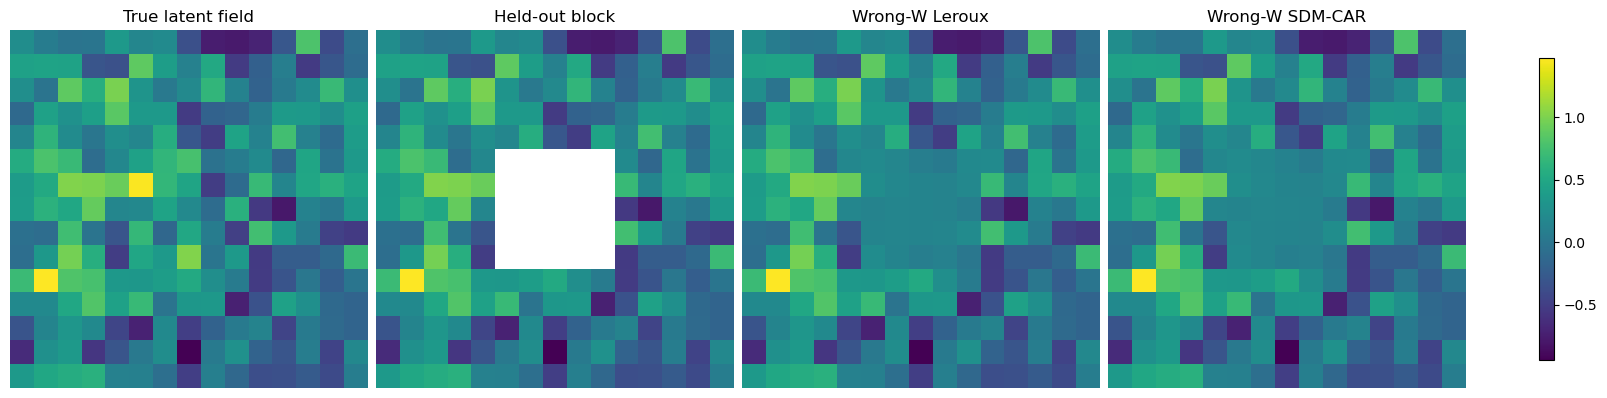

In [52]:
def filled_map(result):
    field = eta_true.copy()

    field[test_mask] = (
        result["prediction"]["mean"]
        .detach()
        .cpu()
        .numpy()
    )

    return field.reshape(N_ROWS, N_COLS)


masked = eta_true.copy()
masked[test_mask] = np.nan

fields = [
    eta_true.reshape(N_ROWS, N_COLS),
    masked.reshape(N_ROWS, N_COLS),
    filled_map(wrong_leroux),
    filled_map(wrong_sdm),
]

titles = [
    "True latent field",
    "Held-out block",
    "Wrong-W Leroux",
    "Wrong-W SDM-CAR",
]

finite_values = np.concatenate(
    [
        field[np.isfinite(field)]
        for field in fields
    ]
)

vmin = finite_values.min()
vmax = finite_values.max()

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    constrained_layout=True,
)

for ax, field, title in zip(
    axes,
    fields,
    titles,
):
    image = ax.imshow(
        field,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    shrink=0.8,
)

plt.show()

## Optional spectral mechanism check

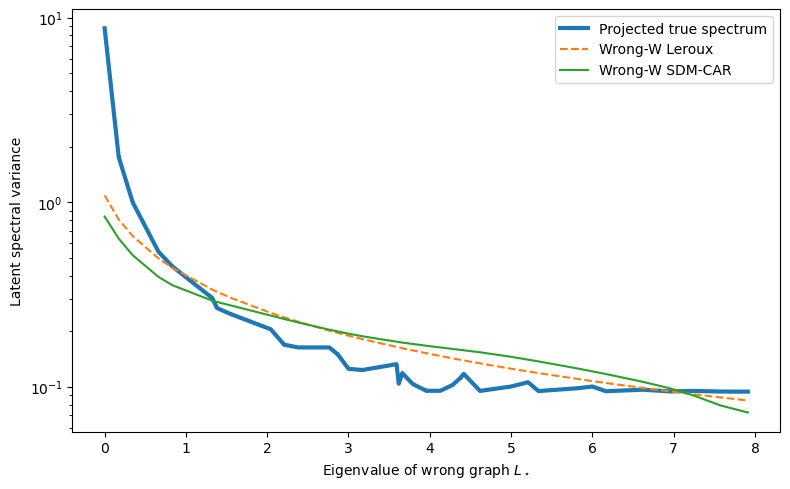

In [53]:
@torch.no_grad()
def posterior_mean_spectrum(
    result,
    draws=512,
):
    model = result["model"]
    lam_t = result["lam_t"]

    spectra = []

    for _ in range(draws):
        theta = model.filter.sample_unconstrained()

        spectra.append(
            model.filter.spectrum(
                lam_t,
                theta,
            )
        )

    return (
        torch.stack(spectra)
        .mean(dim=0)
        .cpu()
        .numpy()
    )


Sigma_true = (
    U_true
    @ np.diag(F_true)
    @ U_true.T
)

target_spectrum = np.diag(
    U_wrong.T
    @ Sigma_true
    @ U_wrong
)

F_wrong_leroux = posterior_mean_spectrum(
    wrong_leroux
)

F_wrong_sdm = posterior_mean_spectrum(
    wrong_sdm
)

order = np.argsort(lam_wrong)

plt.figure(figsize=(8, 5))

plt.plot(
    lam_wrong[order],
    target_spectrum[order],
    linewidth=3,
    label="Projected true spectrum",
)

plt.plot(
    lam_wrong[order],
    F_wrong_leroux[order],
    linestyle="--",
    label="Wrong-W Leroux",
)

plt.plot(
    lam_wrong[order],
    F_wrong_sdm[order],
    label="Wrong-W SDM-CAR",
)

plt.yscale("log")
plt.xlabel(r"Eigenvalue of wrong graph $L_\star$")
plt.ylabel("Latent spectral variance")
plt.legend()
plt.tight_layout()
plt.show()